In [3]:
import numpy as np
import matplotlib.pyplot as plt


def sim_integrator(mu=1.0, sigma=0.5, theta=1.0,
                   T=20000.0, dt=0.005, T_burn=200.0, seed=0):
    rng = np.random.default_rng(seed)
    N      = int(T / dt)
    N_burn = int(T_burn / dt)

    u        = 0.0
    n_spikes = 0
    u_record = []

    for i in range(N):
        # Euler-Maruyama step
        u += mu * dt + np.sqrt(2 * dt) * sigma * rng.standard_normal()

        if u >= theta:           # spike + reset
            if i >= N_burn:
                n_spikes += 1
            u = 0.0
        else:
            if i >= N_burn:
                u_record.append(u)

    return np.array(u_record), n_spikes, T - T_burn




sigma^2 = 0.25
  firing rate:  sim = 0.9689,  theory = 1.0000
  frac below 0: sim = 0.2395, theory = 0.2454

sigma^2 = 1.0
  firing rate:  sim = 0.9405,  theory = 1.0000
  frac below 0: sim = 0.6196, theory = 0.6321

sigma^2 = 4.0
  firing rate:  sim = 0.8882,  theory = 1.0000
  frac below 0: sim = 0.8744, theory = 0.8848



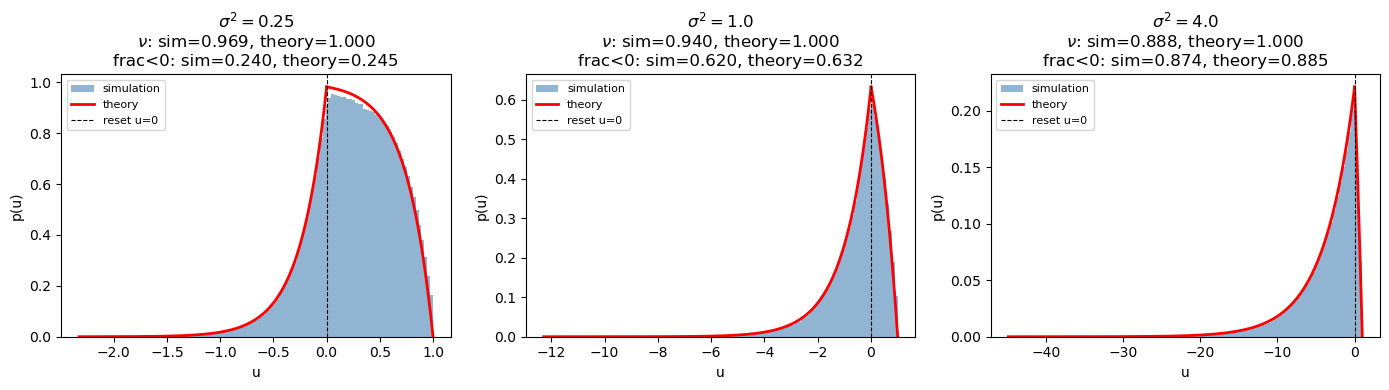

In [4]:
mu    = 1.0
theta = 1.0

cases = [(0.25, np.sqrt(0.25)),
         (1.0,  np.sqrt(1.0)),
         (4.0,  np.sqrt(4.0))]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (sigma2, sigma) in zip(axes, cases):

    u_rec, n_spk, T_meas = sim_integrator(mu=mu, sigma=sigma, theta=theta)

    nu_meas          = n_spk / T_meas
    nu_theory        = mu / theta

    frac_below_meas   = np.mean(u_rec < 0)
    frac_below_theory = (sigma2 / (mu * theta)) * (1 - np.exp(-mu * theta / sigma2))

    print(f"sigma^2 = {sigma2}")
    print(f"  firing rate:  sim = {nu_meas:.4f},  theory = {nu_theory:.4f}")
    print(f"  frac below 0: sim = {frac_below_meas:.4f}, theory = {frac_below_theory:.4f}")
    print()

    # analytical p(u) from part (a)
    nu = nu_theory

    u_sub = np.linspace(0, theta, 500)
    p_sub = (nu / mu) * (1 - np.exp(mu * (u_sub - theta) / sigma2))

    u_neg = np.linspace(u_rec.min() - 0.05, 0, 200)
    p_neg = (nu / mu) * (1 - np.exp(-mu * theta / sigma2)) * np.exp(mu * u_neg / sigma2)

    ax.hist(u_rec, bins=120, density=True, alpha=0.6, color='steelblue', label='simulation')
    ax.plot(u_sub, p_sub, 'r-', lw=2, label='theory')
    ax.plot(u_neg, p_neg, 'r-', lw=2)
    ax.axvline(0, color='k', lw=0.8, ls='--', label='reset u=0')
    ax.set_xlabel('u')
    ax.set_ylabel('p(u)')
    ax.set_title(
        f'$\\sigma^2={sigma2}$\n'
        f'$\\nu$: sim={nu_meas:.3f}, theory={nu_theory:.3f}\n'
        f'frac<0: sim={frac_below_meas:.3f}, theory={frac_below_theory:.3f}'
    )
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('prob5c.png', dpi=150)
plt.show()